In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t',
                   index_col=0)

In [11]:
data

,Unnamed: 0,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length,lid_bitscore
0,0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,...,37.0,37.00,187,178.2,90.0,48.0,42.0,6.0,24,0.0
1,1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,...,30.0,30.00,215,175.3,116.0,49.0,43.0,6.0,23,52.3
2,2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,...,37.0,37.00,214,192.2,117.0,48.0,42.0,6.0,24,59.2
3,3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,...,30.0,30.00,210,168.7,112.0,48.0,43.0,6.0,24,58.3
4,4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,...,37.0,37.00,181,192.9,88.0,44.0,42.0,6.0,21,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8527,9336,111.0,11.257919,49.134618,RS_GCF_905397275.1,-492.694,1.353,10.846,2.780,130.0,...,30.0,28.75,221,195.8,123.0,48.0,43.0,6.0,28,61.7
8528,9337,99.0,11.502591,51.214600,RS_GCF_907163105.1,-494.248,1.290,11.031,2.738,128.0,...,30.0,33.50,193,165.6,122.0,22.0,42.0,6.0,24,0.0
8529,9338,111.0,11.366516,49.484025,RS_GCF_905397435.1,-469.955,1.362,10.810,2.811,133.0,...,27.0,26.40,221,194.9,123.0,48.0,43.0,6.0,28,61.6
8530,9339,108.0,11.479070,49.243296,RS_GCF_910593845.1,-487.960,1.288,10.833,2.731,133.0,...,30.0,29.50,215,190.8,118.0,48.0,42.0,6.0,24,66.3


In [ ]:
# testing code in the readme
import sys
sys.path.append('/data/mhoffert/tools/imbalanced-regression/imdb-wiki-dir/')


from collections import Counter
from scipy.ndimage import convolve1d
from imb_utils import get_lds_kernel_window

In [14]:
data['mean_temp'].min()

3.6202904159999902

In [24]:
# list(np.linspace(3, 82, 80))

In [25]:
# preds, labels: [Ns,], "Ns" is the number of total samples
# preds, = 
labels = data['mean_temp']

def get_bin_idx(label):
    return list(np.linspace(3, 82, 80)).index(np.floor(label))

# assign each label to its corresponding bin (start from 0)
# with your defined get_bin_idx(), return bin_index_per_label: [Ns,] 
bin_index_per_label = [get_bin_idx(label) for label in labels]

# # calculate empirical (original) label distribution: [Nb,]
# # "Nb" is the number of bins
Nb = max(bin_index_per_label) + 1
num_samples_of_bins = dict(Counter(bin_index_per_label))
emp_label_dist = [num_samples_of_bins.get(i, 0) for i in range(Nb)]

In [47]:
# lds_kernel_window: [ks,], here for example, we use gaussian, ks=5, sigma=2
lds_kernel_window = get_lds_kernel_window(kernel='gaussian', ks=8, sigma=2)
# calculate effective label distribution: [Nb,]
eff_label_dist = convolve1d(np.array(emp_label_dist), weights=lds_kernel_window, mode='constant')

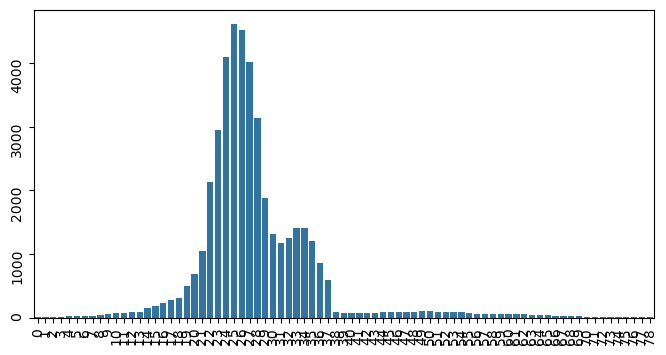

In [48]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(eff_label_dist)
plt.tick_params(rotation=90)

In [ ]:
from fds import FDS

config = dict(feature_dim=..., start_update=0, start_smooth=1, kernel='gaussian', ks=5, sigma=2)

def Network(nn.Module):
    def __init__(self, **config):
        super().__init__()
        self.feature_extractor = ...
        self.regressor = nn.Linear(config['feature_dim'], 1)  # FDS operates before the final regressor
        self.FDS = FDS(**config)

    def forward(self, inputs, labels, epoch):
        features = self.feature_extractor(inputs)  # features: [batch_size, feature_dim]
        # smooth the feature distributions over the target space
        smoothed_features = features    
        if self.training and epoch >= config['start_smooth']:
            smoothed_features = self.FDS.smooth(smoothed_features, labels, epoch)
        preds = self.regressor(smoothed_features)
        
        return {'preds': preds, 'features': features}

In [1]:
# fcnet.py: Define the deep learning (neural network) model
import torch.nn as nn
import torch.nn.functional as F

In [2]:


class FCNet(nn.Module):

    def __init__(self, layers, dropout=None):
        super(FCNet, self).__init__()
        self.fc0 = nn.Linear(13, layers[0])
        self.fc1 = nn.Linear(layers[0], layers[1])
        self.fc2 = nn.Linear(layers[1], layers[2])
        self.fc_final = nn.Linear(layers[-1], 1)

        self.dropout = dropout
        self.use_dropout = True if dropout else False
        if self.use_dropout:
            print(f'Using dropout: {dropout}')
            self.dropout0 = nn.Dropout(p=dropout)
            self.dropout1 = nn.Dropout(p=dropout)
            self.dropout2 = nn.Dropout(p=dropout)
        else:
            self.dropout0 = nn.Identity()
            self.dropout1 = nn.Identity()
            self.dropout2 = nn.Identity()

    def forward(self, x, targets=None, epoch=None):
        x = self.dropout0(F.relu(self.fc0(x)))
        x = self.dropout1(F.relu(self.fc1(x)))
        x = self.dropout2(F.relu(self.fc2(x)))
        x = self.fc_final(x)

        return x

def fcnet1(**kwargs):
    return FCNet([256, 256, 256], **kwargs)

In [4]:
## loss function
def weighted_l1_loss(inputs, targets, weights=None):
    loss = F.l1_loss(inputs, targets, reduction='none')
    if weights is not None:
        loss *= weights.expand_as(loss)
    loss = torch.mean(loss)
    return loss

In [5]:
## Utility functions
# utils.py: Define some utility functions (not the focus of this course).
import os
import shutil
import torch
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal.windows import triang

class AverageMeter(object):
    def __init__(self, name, fmt=':f'):
        self.name = name
        self.fmt = fmt
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

    def __str__(self):
        fmtstr = '{name} {val' + self.fmt + '} ({avg' + self.fmt + '})'
        return fmtstr.format(**self.__dict__)

class ProgressMeter(object):
    def __init__(self, num_batches, meters, prefix=""):
        self.batch_fmtstr = self._get_batch_fmtstr(num_batches)
        self.meters = meters
        self.prefix = prefix

    def display(self, batch):
        entries = [self.prefix + self.batch_fmtstr.format(batch)]
        entries += [str(meter) for meter in self.meters]
        print('\t'.join(entries))

    @staticmethod
    def _get_batch_fmtstr(num_batches):
        num_digits = len(str(num_batches // 1))
        fmt = '{:' + str(num_digits) + 'd}'
        return '[' + fmt + '/' + fmt.format(num_batches) + ']'

def query_yes_no(question):
    """ Ask a yes/no question via input() and return their answer. """
    valid = {"yes": True, "y": True, "ye": True, "no": False, "n": False}
    prompt = " [Y/n] "

    while True:
        print(question + prompt, end=':')
        choice = input().lower()
        if choice == '':
            return valid['y']
        elif choice in valid:
            return valid[choice]
        else:
            print("Please respond with 'yes' or 'no' (or 'y' or 'n').\n")

def prepare_folders(args):
    folders_util = [args.store_root, os.path.join(args.store_root, args.store_name)]
    if os.path.exists(folders_util[-1]) and not args.resume and not args.evaluate:
        if query_yes_no('overwrite previous folder: {} ?'.format(folders_util[-1])):
            shutil.rmtree(folders_util[-1])
            print(folders_util[-1] + ' removed.')
        else:
            raise RuntimeError('Output folder {} already exists'.format(folders_util[-1]))
    for folder in folders_util:
        if not os.path.exists(folder):
            print(f"===> Creating folder: {folder}")
            os.mkdir(folder)

def adjust_learning_rate(optimizer, epoch, args):
    lr = args.lr
    for milestone in args.schedule:
        lr *= 0.1 if epoch >= milestone else 1.
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

def save_checkpoint(args, state, is_best, prefix=''):
    filename = f"{args.store_root}/{args.store_name}/{prefix}ckpt.pth.tar"
    torch.save(state, filename)
    if is_best:
        print("===> Saving current best checkpoint...")
        shutil.copyfile(filename, filename.replace('pth.tar', 'best.pth.tar'))

def calibrate_mean_var(matrix, m1, v1, m2, v2, clip_min=0.1, clip_max=10):
    if torch.sum(v1) < 1e-10:
        return matrix
    if (v1 == 0.).any():
        valid = (v1 != 0.)
        factor = torch.clamp(v2[valid] / v1[valid], clip_min, clip_max)
        matrix[:, valid] = (matrix[:, valid] - m1[valid]) * torch.sqrt(factor) + m2[valid]
        return matrix

    factor = torch.clamp(v2 / v1, clip_min, clip_max)
    return (matrix - m1) * torch.sqrt(factor) + m2

def get_lds_kernel_window(kernel, ks, sigma):
    assert kernel in ['gaussian', 'triang', 'laplace']
    half_ks = (ks - 1) // 2
    if kernel == 'gaussian':
        base_kernel = [0.] * half_ks + [1.] + [0.] * half_ks
        kernel_window = gaussian_filter1d(base_kernel, sigma=sigma) / max(gaussian_filter1d(base_kernel, sigma=sigma))
    elif kernel == 'triang':
        kernel_window = triang(ks)
    else:
        laplace = lambda x: np.exp(-abs(x) / sigma) / (2. * sigma)
        kernel_window = list(map(laplace, np.arange(-half_ks, half_ks + 1))) / max(map(laplace, np.arange(-half_ks, half_ks + 1)))

    return kernel_window

In [6]:
# datasets.py: Define the data iterator (data loader).
from scipy.ndimage import convolve1d
import os
import numpy as np
from torch.utils import data
# from utils import get_lds_kernel_window

In [ ]:
class TempData(data.Dataset):
    '''
    Temperature class definition and iterator
    
    '''
    def __init__(self, data, split='train', reweight='none',
                 lds=False, lds_kernel='gaussian', lds_ks=5, lds_sigma=2):
        self.split = split
        self.data = data
        self.weights = self._prepare_weights(reweight=reweight, lds=lds, lds_kernel=lds_kernel, lds_ks=lds_ks, lds_sigma=lds_sigma)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        index = index % self.data.shape[0]
        feature = self.data[index, :-1]
        label = np.expand_dims(np.asarray(self.data[index, -1]), axis=0)
        weight = np.asarray([self.weights[index]]).astype('float32') if self.weights is not None else np.asarray([np.float32(1.)])
        return feature, label, weight

    def _prepare_weights(self, reweight, max_target=51, lds=False, lds_kernel='gaussian', lds_ks=5, lds_sigma=2):
        assert reweight in {'none', 'inverse', 'sqrt_inv'}
        assert reweight != 'none' if lds else True, \
            "Set reweight to \'sqrt_inv\' (default) or \'inverse\' when using LDS"

        value_dict = {x: 0 for x in range(max_target)}
        labels = self.data[:, -1].tolist()
        # mbr
        for label in labels:
            value_dict[min(max_target - 1, int(label))] += 1
        if reweight == 'sqrt_inv':
            value_dict = {k: np.sqrt(v) for k, v in value_dict.items()}
        elif reweight == 'inverse':
            value_dict = {k: np.clip(v, 5, 1000) for k, v in value_dict.items()}  # clip weights for inverse re-weight
        num_per_label = [value_dict[min(max_target - 1, int(label))] for label in labels]
        if not len(num_per_label) or reweight == 'none':
            return None
        print(f"Using re-weighting: [{reweight.upper()}]")

        if lds:
            lds_kernel_window = get_lds_kernel_window(lds_kernel, lds_ks, lds_sigma)
            print(f'Using LDS: [{lds_kernel.upper()}] ({lds_ks}/{lds_sigma})')
            smoothed_value = convolve1d(
                np.asarray([v for _, v in value_dict.items()]), weights=lds_kernel_window, mode='constant')
            num_per_label = [smoothed_value[min(max_target - 1, int(label))] for label in labels]

        weights = [np.float32(1 / x) for x in num_per_label]
        scaling = len(weights) / np.sum(weights)
        weights = [scaling * x for x in weights]
        return weights